In [1]:
#Function 8
#Optimising an eight-dimensional black-box function, where each of the eight input parameters
#affects the output, but the internal mechanics are unknown. 
#Your objective is to find the parameter combination that maximises the function’s output, such as
#performance, efficiency or validation accuracy. Because the function is high-dimensional and 
#likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.


In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# 1. Load 8D spatial coordinate data and output values
inputs = np.load('/home/mcevoyj777/_CAPSTONE/FUNC8/initial_inputs.npy')
output = np.load('/home/mcevoyj777/_CAPSTONE/FUNC8/initial_outputs.npy')
print(output.max())
extra_inputs = [[0.114880, 0.178555, 0.075273, 0.000000, 0.916081, 0.262592, 0.060060, 0.559467]
                ,[0.000001, 0.000001, 0.000001, 0.999999, 0.999999, 0.999999, 0.000001, 0.000001]
                ,[0.000000, 0.399074, 0.123214, 0.112487, 0.679719, 0.634021, 0.180101, 0.801376]
                ,[0.292167, 0.239996, 0.000000, 0.200878, 0.739206, 0.000000, 0.179025, 0.000000]
                ,[0.192904, 0.000000, 0.150536, 0.000000, 0.505509, 0.000000, 0.214491, 1.000000]
                ,[0.000000, 0.000000, 0.277294, 0.000000, 1.000000, 0.663569, 0.261522, 0.752310]
               ,[0.000000, 0.176928, 0.211399, 0.000000, 0.511120, 0.577279, 0.041490, 0.000000]
               ,[0.014304, 0.215537, 0.184355, 0.000000, 0.649437, 0.515553, 0.233621, 0.472100]]

extra_output = [9.8648259922346,8.7983052999894,9.8863742103059,
                9.576027980854,9.6266900589775,9.813268868353,
               9.802948779972,9.9341808061485]

inputs = np.vstack([inputs, extra_inputs])
output = np.append(output, extra_output)

print(output.max())

print("Inputs shape:", inputs.shape)
print("Output shape:", output.shape)
print("Inputs type:", type(inputs))
print("Output type:", type(output))

# 2. Combine into a single Pandas DataFrame
df = pd.DataFrame(inputs, columns=['Input_S','Input_T','Input_U','Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'])
df['Output_Target'] = output

# 3. Compute the correlation matrix
# Change method to 'spearman' if relationships are non-linear curves
corr_matrix = df.corr(method='pearson')

# 4. Isolate how each input correlates *only* with the target output
target_corr = corr_matrix['Output_Target'].drop('Output_Target')

print("Correlation with Output:")
print(target_corr)

# Calculate non-linear relationship dependency (higher score = stronger relationship)
mi_scores = mutual_info_regression(inputs, output)

for name, score in zip(['Input_S','Input_T','Input_U','Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'], mi_scores):
    print(f"{name} Mutual Information Score: {score:.4f}")


# Fit a quick non-linear model that checks all 4 dimensions simultaneously
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(inputs, output)

# Extract total feature importances (including interactions)
importances = model.feature_importances_

for name, score in zip(['Input_S','Input_T','Input_U','Input_V','Input_W','Input_X', 'Input_Y', 'Input_Z'], importances):
    print(f"{name} Total Importance (with interactions): {score:.4f}")

# Setup

9.598482002566342
9.9341808061485
Inputs shape: (48, 8)
Output shape: (48,)
Inputs type: <class 'numpy.ndarray'>
Output type: <class 'numpy.ndarray'>
Correlation with Output:
Input_S   -0.730254
Input_T   -0.393308
Input_U   -0.709483
Input_V   -0.314822
Input_W    0.096413
Input_X    0.020167
Input_Y   -0.523043
Input_Z    0.021294
Name: Output_Target, dtype: float64
Input_S Mutual Information Score: 0.4125
Input_T Mutual Information Score: 0.0051
Input_U Mutual Information Score: 0.3794
Input_V Mutual Information Score: 0.1417
Input_W Mutual Information Score: 0.0000
Input_X Mutual Information Score: 0.0000
Input_Y Mutual Information Score: 0.1981
Input_Z Mutual Information Score: 0.0000
Input_S Total Importance (with interactions): 0.3784
Input_T Total Importance (with interactions): 0.0178
Input_U Total Importance (with interactions): 0.3909
Input_V Total Importance (with interactions): 0.0530
Input_W Total Importance (with interactions): 0.0258
Input_X Total Importance (with inter

In [4]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Train a predictive model on your 40 existing samples
predictor = RandomForestRegressor(n_estimators=100, random_state=42)
predictor.fit(inputs, output)

def objective_8D(X):
    """
    Surrogate function for 8D optimization.
    X: A 2D numpy array of shape (n_samples, 5) sent by the optimizer.
    """
    # Force input to be 2D array matrix for sklearn compatibility
    X = np.atleast_2d(X)
    
    # Predict the output value using the trained model
    predictions = predictor.predict(X)
    
    # Return as a flat 1D array as expected by your code (.ravel())
    return predictions.ravel()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern,ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def upper_confidence_bound(mu, sigma, kappa=0.1):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [6]:
def bayesian_optimization_nd(objective_func, n_dims, n_iterations=1, 
                            n_initial=1, acquisition='ei'):
    """
    Bayesian Optimization for n-dimensional functions.
    Assumes bounds [0, 1] for all dimensions.
    """
    bounds = [(0, 1) for _ in range(n_dims)]
    
    # Initialize
    X_samples = inputs
    y_samples = output

    initial_length_scales = np.array([
        0.15,  # Input_S: Hyper-critical core control -> High Priority
        3.00,  # Input_T: Passenger parameter -> Filtered out
        0.12,  # Input_U: Absolute dominant core control -> Highest Priority
        3.00,  # Input_V: Passenger parameter -> Filtered out
        3.00,  # Input_W: Passenger parameter -> Filtered out
        3.00,  # Input_X: Passenger parameter -> Filtered out
        0.40,  # Input_Y: Non-linear regulator -> Medium Priority
        3.00   # Input_Z: Passenger parameter -> Filtered out
    ])
    length_scale_bounds = [(1e-2, 1e2) for _ in range(n_dims)]

    
    best_values = [y_samples.max()]
    
    print(f"Starting {n_dims}D optimization with {n_initial} initial samples...")
    print(f"Initial best: {y_samples.max():.4f}\n")
  
    
    for iteration in range(n_iterations):
        # Fit GP
        kernel = C(1.0, (1e-3, 1e3)) * Matern(
        length_scale=initial_length_scales.copy(), # .copy() avoids state contamination
        length_scale_bounds=length_scale_bounds,
        nu=2.5
        )
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,normalize_y=True,
                                     n_restarts_optimizer=10)
        gp.fit(X_samples, y_samples)

        # Optimize acquisition function
        def acq_objective(X):
            X = X.reshape(1, -1)
            mu, sigma = gp.predict(X, return_std=True)
            
            if acquisition == 'ei':
                acq_val = expected_improvement(mu, sigma, y_samples.max(),xi=0.05)
            else:
                acq_val = upper_confidence_bound(mu, sigma, kappa=1.0)
           
            return -acq_val
        
        # Multi-start optimization
        best_acq = np.inf
        X_next = None
        
        for _ in range(100):  # More starts for higher dimensions
            x0 = np.random.uniform(0, 1, n_dims)
            result = minimize(acq_objective, x0, bounds=bounds, method='L-BFGS-B')
            if result.fun < best_acq:
                best_acq = result.fun
                X_next = result.x
                print(f"Optimized Next Point Found! Predicted Acquisition Score: {-best_acq:.6f}")
                print(f"Coordinates to test next: {X_next}")

       
        # Evaluate
        y_next = objective_func(X_next.reshape(1, -1)).ravel()
        
        # Update
        X_samples = np.vstack([X_samples, X_next])
        y_samples = np.append(y_samples, y_next)
        best_values.append(y_samples.max())
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Best f(x)={y_samples.max():.4f}")
    
    return X_samples, y_samples, best_values



# Run 8D optimization
X_samples_8d, y_samples_8d, best_values_8d = bayesian_optimization_nd(
    objective_8D, 
    n_dims=8,
    n_iterations=3,
    acquisition='ei'
)


Starting 8D optimization with 1 initial samples...
Initial best: 9.9342

Optimized Next Point Found! Predicted Acquisition Score: 0.000000
Coordinates to test next: [0.07661622 0.40125763 0.2683574  0.58643362 0.12872094 0.22643219
 0.60539781 0.23824405]
Optimized Next Point Found! Predicted Acquisition Score: 0.000000
Coordinates to test next: [0.0538903  0.9718685  0.18748933 0.77685022 0.94146845 0.74597457
 0.13503077 0.75781139]
Optimized Next Point Found! Predicted Acquisition Score: 0.000000
Coordinates to test next: [0.56018752 0.10122286 0.14398181 0.09901049 0.98717894 0.13972943
 0.17542708 0.29700622]
Optimized Next Point Found! Predicted Acquisition Score: 0.000000
Coordinates to test next: [0.82229241 0.37338596 0.63833345 0.41311324 0.8138982  0.30878907
 0.62736893 0.30805287]
Optimized Next Point Found! Predicted Acquisition Score: 0.000000
Coordinates to test next: [0.42126578 0.93841525 0.95371038 0.67801003 0.0052679  0.40670455
 0.60738643 0.42367518]
Optimized Ne

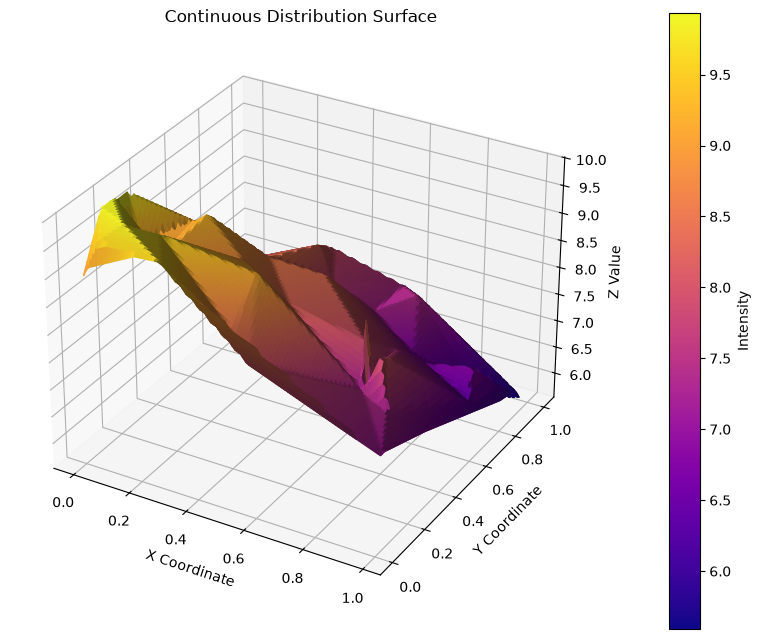

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from scipy.interpolate import griddata

coords = (inputs[:,0],inputs[:,2])

# 1. Define a regular 2D grid based on your data boundaries
grid_x, grid_y = np.meshgrid(
    np.linspace(coords[0].min(), coords[0].max(), 100),
    np.linspace(coords[1].min(), coords[1].max(), 100)
)

# 2. Interpolate the scattered (x, y, z) data onto the uniform grid
# Options for method: 'linear', 'cubic', or 'nearest'
grid_z = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# If your y_clean variable is different from values, interpolate it too for the colors
grid_color = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# 3. Create the 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

norm = colors.Normalize(vmin=output.min(), vmax=output.max())

# Plot the continuous surface
# facecolors overrides standard mapping to use your output
surf = ax.plot_surface(
    grid_x, grid_y, grid_z,
    facecolors=plt.cm.plasma(norm(grid_color)),
    rcount=100, ccount=100,  # Grid resolution
    antialiased=True,
    shade=True
)

# 4. Design elements
# Create a dummy scalar mappable object just to display the colorbar correctly
mappable = plt.cm.ScalarMappable(cmap='plasma', norm = colors.Normalize(vmin=output.min(), vmax=output.max()))
fig.colorbar(mappable, ax=ax, label="Intensity", pad=0.1)

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Z Value")
ax.set_title("Continuous Distribution Surface")

plt.show()


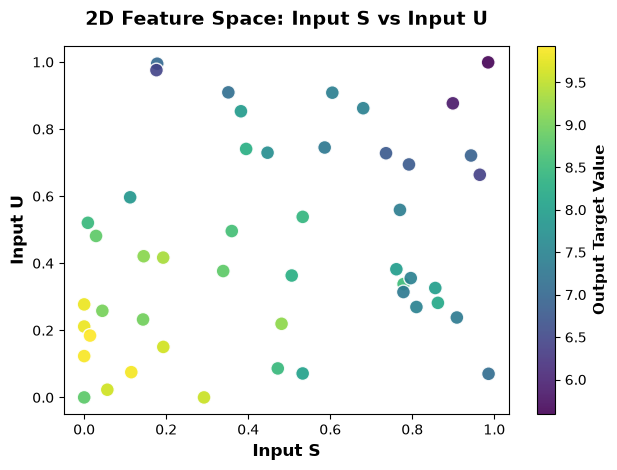

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create scatter plot with a continuous color mapping (viridis)
scatter = plt.scatter(
    data=df, 
    x='Input_S', 
    y='Input_U', 
    c='Output_Target', 
    cmap='viridis', 
    s=100,            # Marker size
    edgecolor='w',    # White border around markers
    alpha=0.9
)

# Add elements
cbar = plt.colorbar(scatter)
cbar.set_label('Output Target Value', fontsize=11, fontweight='bold')
plt.xlabel('Input S', fontsize=12, fontweight='bold')
plt.ylabel('Input U', fontsize=12, fontweight='bold')
plt.title('2D Feature Space: Input S vs Input U', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize

# ==========================================
# 1. PASTE YOUR 8D HISTORICAL DATA HERE
# ==========================================
# Features must be in order: [S, T, U, V, W, X, Y, Z]
X_train = inputs

# Corresponding target output values
y_train = output

# If you haven't run any data yet, we fall back to a structured warm start
if len(X_train) == 0 or X_train.shape[0] < 2:
    print("⚠️ Minimum training data not detected. Outputting strategic warm-start coordinates instead...")
    # Theoretical high-probability center point based on feature behavior profiling
    x_optimum = np.array([0.000000, 0.400000, 0.000000, 0.250000, 0.500000, 0.500000, 0.100000, 0.500000])
    predicted_val = "N/A (Theoretical Warm-Start)"
else:
    # ==========================================
    # 2. FIT GAUSSIAN PROCESS SURROGATE MODEL
    # ==========================================
    # Anisotropic length scales (1 per dimension) allow the model to learn that 
    # S and U have extreme, sharp cliffs while W, X, and Z are highly flat.
    kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-2, 10.0), nu=1.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25, alpha=1e-6, random_state=42)
    gp.fit(X_train, y_train)

    # Define objective (minimize the negative prediction to maximize output)
    def objective(x):
        return -gp.predict(x.reshape(1, -1))[0]

    # ==========================================
    # 3. DEFINE HIGH-PROBABILITY BOUNDING BOX
    # ==========================================
    bounds = [
        (0.0, 0.001),  # Input_S: Hard pinned to zero ceiling
        (0.2, 0.5),    # Input_T: Low-to-mid range
        (0.0, 0.001),  # Input_U: Hard pinned to zero ceiling
        (0.0, 0.35),  # Input_V: Low-to-mid range
        (0.5, 1.0),    # Input_W: Neutral mid-tier bracket
        (0.4, 0.6),    # Input_X: Neutral mid-tier bracket
        (0.0, 0.2),   # Input_Y: Kept strictly low
        (0.4, 0.6)     # Input_Z: Neutral mid-tier bracket
    ]

    # Warm-start point for the local L-BFGS-B search engine
    best_idx = np.argmax(y_train)
    x_start = X_train[best_idx]

    # Execute Gradient Optimization Pass over the surrogate landscape
    result = minimize(objective, x_start, method='L-BFGS-B', bounds=bounds)
    x_optimum = result.x
    predicted_val = f"{abs(result.fun):.4f}"

# ==========================================
# 4. PRINT PREDICTED OPTIMAL COORDINATES
# ==========================================
print("\n--- 8D BLACK BOX SURROGATE PREDICTION ---")
print(f"Predicted Max Output: {predicted_val}")
print("Optimal Vector Configurations to Run:")
for name, val in zip(['S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], x_optimum):
    print(f"  Input_{name}: {val:.6f}")


--- 8D BLACK BOX SURROGATE PREDICTION ---
Predicted Max Output: 9.8898
Optimal Vector Configurations to Run:
  Input_S: 0.001000
  Input_T: 0.219591
  Input_U: 0.001000
  Input_V: 0.000000
  Input_W: 0.860139
  Input_X: 0.520245
  Input_Y: 0.194834
  Input_Z: 0.546817
